In [1]:
import pandas as pd
import numpy as np
import itertools

In [2]:
from _utils_spline import eval_spline_basis_equispaced_numeric, difference_matrix
import pickle
import os
import matplotlib.pyplot as plt

In [3]:
directory_path = "../p-splines/"
data_path = os.path.join(directory_path, "data.pkl")
with open(data_path, "rb") as data_file:
        data = pickle.load(data_file)

In [4]:
spline_degree = 3
n_internal_knots = 20
order = 2
x_data = data[('f1', 1.0)][0][0]
x_order = np.argsort(x_data)

In [5]:
eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
B = eval_B['B']
k = B.shape[1]

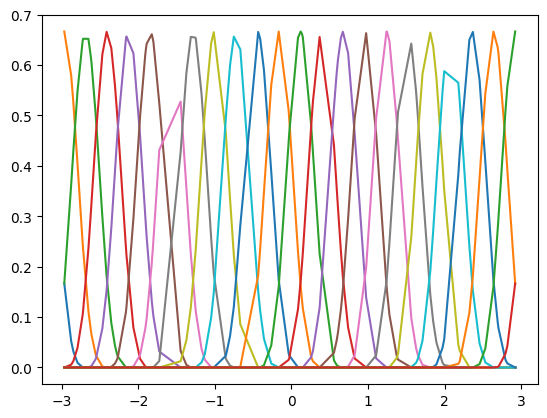

In [6]:
plt.plot(x_data[x_order], B[x_order])
plt.show()

In [150]:
c = np.ones(x_data.shape[0]).reshape(-1, 1)
c = c/np.linalg.norm(c)
l = x_data.reshape(-1, 1)
l = l - (c.T@l/(np.linalg.norm(c)**2))*c
l = l/np.linalg.norm(l)

In [115]:
B0 = B[:, 0].copy()
B0 = B0 - (c@B0/(np.linalg.norm(c)**2))*c
plt.plot(x_data[x_order], B0[x_order])
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 1)

In [151]:
C = B.copy()
C = C - (c.T@C/(np.linalg.norm(c)**2))*c
C = C - (l.T@C/(np.linalg.norm(l)**2))*l

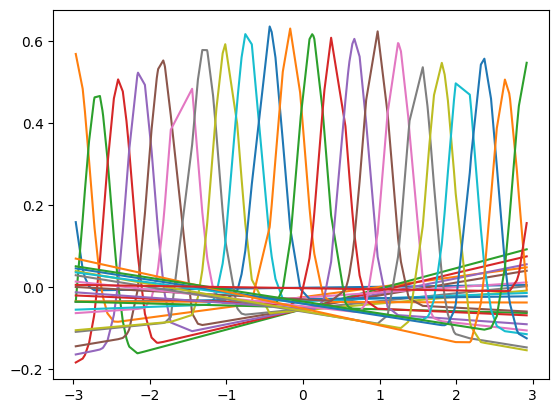

In [152]:
plt.plot(x_data[x_order], C[x_order])
plt.show()

In [153]:
B.shape, np.linalg.matrix_rank(B), C.shape, np.linalg.matrix_rank(C)

((100, 24), np.int64(24), (100, 24), np.int64(22))

In [154]:
K = difference_matrix(k, order=2).T @ difference_matrix(k, order=2)
K_pinv = np.linalg.pinv(K)
K.shape, np.linalg.matrix_rank(K), K_pinv.shape, np.linalg.matrix_rank(K_pinv)

((24, 24), np.int64(22), (24, 24), np.int64(22))

In [155]:
PB = B @ K_pinv @ B.T
PB.shape, np.linalg.matrix_rank(PB)

((100, 100), np.int64(22))

In [156]:
PC = C @ K_pinv @ C.T
PC.shape, np.linalg.matrix_rank(PC)

((100, 100), np.int64(22))

In [157]:
n, k = B.shape

In [181]:
X = B.copy()
#X = C.copy()

# Penalised
r = k - order
K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
K_pinv = np.linalg.pinv(K)

VK_pinv, UK_pinv = np.linalg.eigh(K_pinv)
#X_plot_p = X_plot @ (UK_pinv[:, -r:] * np.sqrt(VK_pinv[-r:]))
V, U = np.linalg.eigh(X@K_pinv@X.T)
print(np.linalg.matrix_rank(X@K_pinv@X.T))
Vp = V[-r:]
Up = U[:, -r:]
U0 = U[:, :-r]
Xp = Up*np.sqrt(Vp)

# Phi_p = K_pinv @ X.T @ Up / np.sqrt(Vp)
#X_plot_p = X_plot @ Phi_p

# Unpenalised
w_trend = np.arange(k)
w_trends = np.array([w_trend**d for d in range(1, order)]).T
w_trends = w_trends - w_trends.mean(axis=0)
X0 = B@w_trends
#X0 = l
#X0_plot = B_plot@w_trends
#X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

#X_plot_0 = X_plot@w_trends / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

#w_p = pm.Normal("w_p",mu=0, tau=tau_p, shape=r, dims="w_p_dim")
#w_0 = pm.Normal("w_0", mu=0, tau=tau, shape=(order-1), dims="w_0_dim")
X = np.hstack([Xp, X0])
#X_plot = np.hstack([X_plot_p, X_plot_0])
#f = pm.math.dot(Xp, w_p) + pm.math.dot(X0, w_0)

22


In [182]:
X = X / np.linalg.norm(X, axis=0)

(100, 23) 23


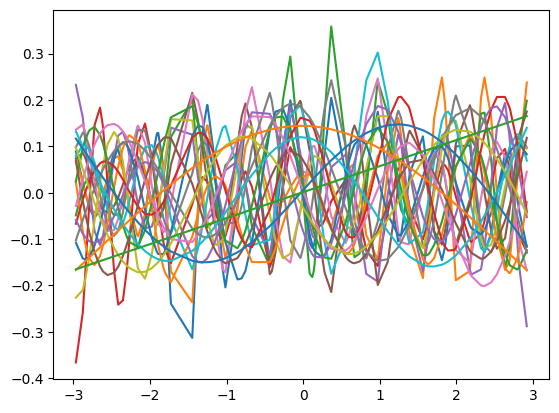

In [183]:
print(X.shape, np.linalg.matrix_rank(X))
plt.plot(x_data[x_order], X[x_order])
plt.show()

<Axes: >

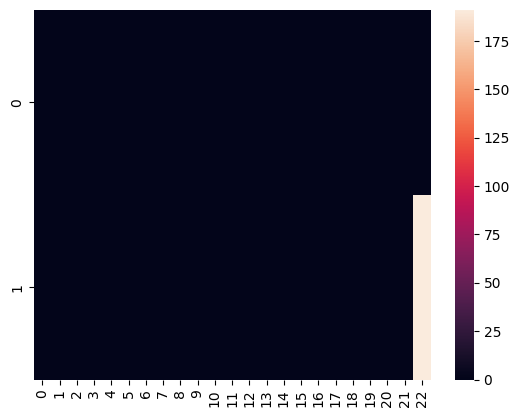

In [39]:
from seaborn import heatmap
heatmap(X0_ortho.T@X)

In [7]:
X = B.copy()
X_plot = B.copy()

w_trend = np.arange(k)
w_trends = np.array([w_trend**d for d in range(0, order)]).T
X0 = X@w_trends
X0_plot = X_plot@w_trends

for c in range(X0.shape[1]):
    col = X0[:, c]
    col_plot = X0_plot[:, c]

    for c0 in range(c):
        col0 = X0[:, c0]
        col0_plot = X0_plot[:, c0]
        col = col - (col0.T@col/np.linalg.norm(col0)**2)*col0
        col_plot = col_plot - (col0.T@col/np.linalg.norm(col0)**2)*col0_plot

        X0[:, c] = col
        X0_plot[:, c] = col_plot

X0 = X0[:, 1:]
X0_plot = X0_plot[:, 1:]

X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))
X0_plot = X0_plot / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))
#X0 = X0/np.linalg.norm(X0, axis=0)
#X0_plot = X0_plot/np.linalg.norm(X0_plot, axis=0)

In [36]:
X = B.copy()
X_plot = B.copy()

In [37]:
# Unpenalised trends (can construct with spline weight trends)
w_trend = np.arange(k)
w_trends = np.array([w_trend**d for d in range(0, order)]).T
X0 = X@w_trends
X0_plot = X_plot@w_trends

for c in range(X0.shape[1]):
    col = X0[:, c]
    col_plot = X0_plot[:, c]

    for c0 in range(c):
        col0 = X0[:, c0]
        col0_plot = X0_plot[:, c0]
        col = col - (col0.T@col/np.linalg.norm(col0)**2)*col0
        col_plot = col_plot - (col0.T@col/np.linalg.norm(col0)**2)*col0_plot

        X0[:, c] = col
        X0_plot[:, c] = col_plot

X0_ortho = X0.copy()
X0 = X0[:, 1:]
X0_ortho_plot = X0_plot.copy()
X0_plot = X0_plot[:, 1:]

X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))
X0_plot = X0_plot / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))
#X0 = X0/np.linalg.norm(X0, axis=0)
#X0_plot = X0_plot/np.linalg.norm(X0_plot, axis=0)

# ortho
for c in range(X0_ortho.shape[1]):
    col = X0_ortho[:, c].reshape(-1, 1)
    col_plot = X0_ortho_plot[:, c].reshape(-1, 1)

    X = X - (col.T@X/np.linalg.norm(col)**2).reshape(-1, 1).T*col
    X_plot = X_plot - (col.T@X/np.linalg.norm(col)**2)*col_plot
print(X.shape, np.linalg.matrix_rank(X))

# Penalised
r = k - order
K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
K_pinv = np.linalg.pinv(K)

VK_pinv, UK_pinv = np.linalg.eigh(K_pinv)
#X_plot_p = X_plot @ (UK_pinv[:, -r:] * np.sqrt(VK_pinv[-r:]))
V, U = np.linalg.eigh(X@K_pinv@X.T)
Vp = V[-r:]
Up = U[:, -r:]
U0 = U[:, :-r]
Xp = Up*np.sqrt(Vp)

#X = Xp
X = np.hstack([Xp, X0])
#X_plot = np.hstack([X_plot_p, X_plot_0])

(100, 24) 22


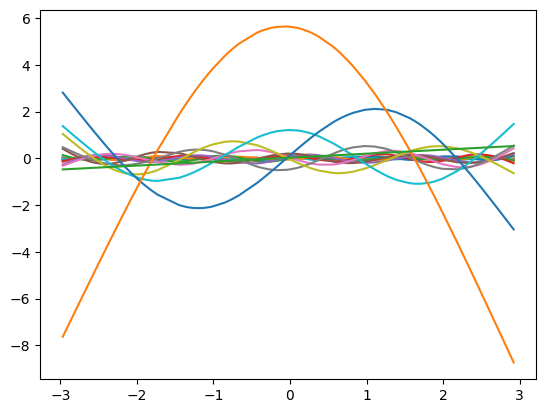

In [38]:
plt.plot(x_data[x_order], X[x_order])
plt.show()


---

In [41]:
def stratified_shuffle(df, stratify_cols, random_cols, random_state=None):
    df = df.sort_values(stratify_cols+random_cols).reset_index(drop=True)
    
    unique_r = df[random_cols].drop_duplicates()
    n_unique_r = len(unique_r)
    unique_g = df[stratify_cols].drop_duplicates()
    n_unique_g = len(unique_g)

    new_df = pd.DataFrame()
    for g in range(n_unique_g):
        new_df = pd.concat([new_df, df[g*n_unique_r:(g+1)*n_unique_r].sample(frac=1).reset_index(drop=True)], ignore_index=True)
    df = new_df
    new_df = pd.DataFrame()
    for r in range(n_unique_r):
        new_df = pd.concat([new_df, df[r::n_unique_r]], ignore_index=True)
    df = new_df
    new_df = pd.DataFrame()
    for r in range(n_unique_r):
        new_df = pd.concat([new_df, df[r*n_unique_g:(r+1)*n_unique_g].sample(frac=1).reset_index(drop=True)], ignore_index=True)
    df = new_df
    return df

In [42]:
stratified_shuffle(df, ['group'], ['replication'], random_state=42)

,group,replication
0,0,8
1,2,6
2,3,9
3,1,9
4,3,1
5,2,8
6,1,7
7,0,6
8,0,9
9,1,8


In [39]:
group = np.arange(4)
replication = np.arange(10)
df = pd.DataFrame(list(itertools.product(group, replication)), columns=['group', 'replication'])
df = df.sort_values(['group', 'replication']).reset_index(drop=True)

In [ ]:
unique_replications = df['replication'].unique()
n_unique_replications = len(unique_replications)
unique_groups = df['group'].unique()
n_unique_groups = len(unique_groups)

new_df = pd.DataFrame()
for g in range(n_unique_groups):
    new_df = pd.concat([new_df, df[g*n_unique_replications:(g+1)*n_unique_replications].sample(frac=1).reset_index(drop=True)], ignore_index=True)
df = new_df
new_df = pd.DataFrame()
for r in range(n_unique_replications):
    new_df = pd.concat([new_df, df[r::n_unique_replications]], ignore_index=True)
df = new_df
new_df = pd.DataFrame()
for r in range(n_unique_replications):
    new_df = pd.concat([new_df, df[r*n_unique_groups:(r+1)*n_unique_groups].sample(frac=1).reset_index(drop=True)], ignore_index=True)
df = new_df

In [36]:
df

,group,replication
0,3,3
1,2,2
2,1,5
3,0,1
4,0,3
5,3,9
6,1,4
7,2,6
8,2,7
9,1,9


In [ ]:
unique_replications = tasks_df['replication'].unique()
n_replications = len(unique_replications)
unique_tasks_df = tasks_df.drop_duplicates(subset=['f', 'sigma', 'implementation', 'penalised', 'builder'])
n_unique_tasks = len(unique_tasks_df)
# Randomise replication order within each task
group_cols = ['f', 'sigma', 'implementation', 'penalised', 'builder']
print(tasks_df.columns)
tasks_df = (
    tasks_df.groupby(
        group_cols,
        group_keys=False
    )
    .apply(lambda g: g.sample(frac=1))
    .reset_index(drop=True)
)
print(tasks_df.columns)
# Assign a batch number within each task
tasks_df['batch'] = tasks_df.groupby(group_cols).cumcount()
# Shuffle within each batch
tasks_df = (
    tasks_df.groupby('batch', group_keys=False)
    .apply(lambda g: g.sample(frac=1))
    .reset_index(drop=True)
    .drop(columns='batch')
)
print(tasks_df.head(20))
sys.exit()
# Create balanced batches
batches = []
for i in range(n_replications):
    batches.append(
        tasks_df.groupby(
            ['f','sigma','implementation','penalised','builder'],
            group_keys=False
        )
        .nth(i)
        .sample(frac=1)
    )

tasks_df = pd.concat(batches, ignore_index=True)
print(tasks_df.head(20))
sys.exit()

tasks_df = tasks_df.sample(frac=1, random_state=42).reset_index(drop=True)
tasks_df = tasks_df.sort_values(['f', 'sigma', 'implementation', 'penalised', 'builder']).reset_index(drop=True)
unique_replications = tasks_df['replication'].unique()
n_replications = len(unique_replications)
unique_tasks_df = tasks_df.drop_duplicates(subset=['f', 'sigma', 'implementation', 'penalised', 'builder'])
n_unique_tasks = len(unique_tasks_df)
new_tasks_df = pd.DataFrame()
for i in range(n_replications):
    new_tasks_df = pd.concat([new_tasks_df, tasks_df[i::n_replications]], ignore_index=True)
tasks_df = new_tasks_df
new_tasks_df = pd.DataFrame()
for i in range(n_replications):
    new_tasks_df = pd.concat([new_tasks_df, tasks_df[i*n_unique_tasks:(i+1)*n_unique_tasks].sample(frac=1).reset_index(drop=True)], ignore_index=True)
tasks_df = new_tasks_df
print(tasks_df.head(20))
sys.exit()

unique_replications = tasks_df['replication'].unique()
np.random.shuffle(unique_replications)
print(unique_replications)
n_replications = len(unique_replications)
#tasks_df = tasks_df.sample(frac=1, random_state=42).reset_index(drop=True)
tasks_df = tasks_df.sort_values(['replication', 'f', 'sigma', 'implementation', 'penalised', 'builder']).reset_index(drop=True)
unique_tasks_df = tasks_df.drop_duplicates(subset=['f', 'sigma', 'implementation', 'penalised', 'builder'])
n_unique_tasks = len(unique_tasks_df)
tasks_df['replication'] = list(itertools.chain.from_iterable([[r]*n_unique_tasks for r in unique_replications]))
new_tasks_df = pd.DataFrame()
for i in range(n_replications):
    new_tasks_df = pd.concat([new_tasks_df, tasks_df[i*n_unique_tasks:(i+1)*n_unique_tasks].sample(frac=1, random_state=42).reset_index(drop=True)], ignore_index=True)
tasks_df = new_tasks_df
#new_tasks_df = pd.DataFrame()
#for i in range(n_replications):
    #new_tasks_df = pd.concat([new_tasks_df, tasks_df[i::n_replications]], ignore_index=True)
#tasks_df = new_tasks_df
print(tasks_df.head(20))
sys.exit()